# Feedforward Neural Network (FNN) for Wind Speed Forecasting
## Dataset 1

This notebook implements FNN (MLPRegressor)-based wind speed forecasting with four modelling strategies:
1. **Original Model** – Default hyperparameters (no tuning)
2. **Grid Search** – Exhaustive hyperparameter search with TimeSeriesSplit CV
3. **Randomized Search** – Stochastic hyperparameter search with TimeSeriesSplit CV
4. **Optuna** – TPE-based Bayesian hyperparameter optimisation with TimeSeriesSplit CV

**Key design decisions:**
- First 80% of observations → training; last 20% → testing (chronological, no shuffling)
- Hyperparameter tuning is performed **exclusively on training data** using `TimeSeriesSplit` (5 folds)
- `StandardScaler` is **fit on training data only** and reused across all sections to prevent data leakage
- Global random seed: **42**

# ─────────────────────────────────────────
# SECTION 0 — PACKAGE INSTALLATION
# ─────────────────────────────────────────

In [8]:
# Install required packages (run once)
!pip install statsmodels optuna tabulate --quiet

# ─────────────────────────────────────────
# SECTION 1 — IMPORTS & GLOBAL SETTINGS
# ─────────────────────────────────────────

In [9]:
# Standard libraries
import sys
import os
import random
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn — preprocessing & model selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

# Scipy — statistical distributions for RandomizedSearchCV
from scipy.stats import uniform

# Optuna — Bayesian hyperparameter optimisation
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress verbose trial logs

# Tabulate — pretty-print summary tables
from tabulate import tabulate

# ── Global random seed (reproducibility) ──
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'Random seed set to: {RANDOM_SEED}')

Random seed set to: 42


# ─────────────────────────────────────────
# SECTION 2 — DATA LOADING
# ─────────────────────────────────────────

In [10]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                            mean_absolute_percentage_error, r2_score)
import pandas as pd

# Load data from the new Google Drive link
file_id = "1pI2WC2uOQARK3ayA6H4c1Eu2IRqURXbR"
download_url = f"https://drive.google.com/uc?id={file_id}"

# Read the data
df = pd.read_csv(download_url)

# Backup original DataFrame
df_backup = df.copy()

# Create datetime directly from differently named columns
df['Date'] = pd.to_datetime({
    'year': df['YEAR'],
    'month': df['MO'],
    'day': df['DY']
})

# Set Date as the index
df = df.set_index('Date')

# Drop unnecessary columns
df = df.drop(columns=["YEAR", "MO", "DY"])

# Display the DataFrame (optional in scripts)
print(df.head())

            WS10M_lag1     RH  MIN_TEMP   PREC    WD_sin    WD_cos  AVG_TEMP  \
Date                                                                           
2013-01-03        4.25  86.26     23.42  13.42  0.439939  0.898028      26.4   
2013-01-04        4.75  86.31     22.93   8.79  0.424199  0.905569      25.1   
2013-01-05        5.74  86.88     22.17   2.60  0.563526  0.826098      26.9   
2013-01-06        5.79  88.09     23.47   1.65  0.460200  0.887815      27.3   
2013-01-07        4.52  93.04     24.04  27.41  0.368125  0.929776      25.9   

            WS10M_lag2  SURF_PRESSSURE  MAX_TEMP  RH_lag1  WD_sin_lag1  \
Date                                                                     
2013-01-03        3.99           99.68     28.38    86.19     0.500000   
2013-01-04        4.25           99.65     27.58    86.26     0.439939   
2013-01-05        4.75           99.50     26.16    86.31     0.424199   
2013-01-06        5.74           99.47     27.75    86.88     0.56352

# ─────────────────────────────────────────
# SECTION 3 — TRAIN / TEST SPLIT
# ─────────────────────────────────────────

In [11]:
# Target variable: wind speed at 10 m (WS10M)
# Features: all remaining meteorological predictors

X = df.drop(columns=['WS10M'])   # Feature matrix
y = df['WS10M']                  # Target vector

# ── Chronological 80/20 split — NO random shuffling (time series integrity) ──
split_index = int(len(X) * 0.8)  # 80% train, 20% test

X_train = X.iloc[:split_index]   # Training features
y_train = y.iloc[:split_index]   # Training target

X_test  = X.iloc[split_index:]   # Testing features
y_test  = y.iloc[split_index:]   # Testing target

print(f'Total samples : {len(df)}')
print(f'Training set  : {X_train.shape[0]} samples ({X_train.index[0].date()} → {X_train.index[-1].date()})')
print(f'Testing set   : {X_test.shape[0]}  samples ({X_test.index[0].date()} → {X_test.index[-1].date()})')

Total samples : 4015
Training set  : 3212 samples (2013-01-03 → 2021-10-19)
Testing set   : 803  samples (2021-10-20 → 2023-12-31)


# ─────────────────────────────────────────
# SECTION 4 — FEATURE SCALING
# ─────────────────────────────────────────

In [12]:
# ── IMPORTANT: Scaler is fit on TRAINING DATA ONLY to prevent data leakage ──
# The same scaler parameters (mean, std) are then applied to the test set.
# This single scaler instance is reused across ALL four modelling sections
# so that no section can inadvertently re-fit the scaler on test data.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, then transform
X_test_scaled  = scaler.transform(X_test)        # Transform test using train statistics only

print('Scaling complete.')
print(f'X_train_scaled shape : {X_train_scaled.shape}')
print(f'X_test_scaled  shape : {X_test_scaled.shape}')

Scaling complete.
X_train_scaled shape : (3212, 15)
X_test_scaled  shape : (803, 15)


# ─────────────────────────────────────────
# SECTION 5 — HELPER FUNCTIONS
# ─────────────────────────────────────────

In [13]:
def evaluate_metrics(y_true, y_pred, label=''):
    """
    Compute and print regression performance metrics.

    Parameters
    ----------
    y_true : array-like  — Ground-truth target values
    y_pred : array-like  — Model predictions
    label  : str         — Prefix label for printed output

    Returns
    -------
    Tuple: (MSE, RMSE, MAE, MAPE, R²)
    """
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    # MAPE: guard against division by zero using np.where
    mape = np.mean(
        np.where(np.abs(y_true) > 1e-8,
                 np.abs((y_true - y_pred) / y_true) * 100,
                 0.0)
    )
    r2   = r2_score(y_true, y_pred)

    print(f'{label} MSE  : {mse:.4f}')
    print(f'{label} RMSE : {rmse:.4f}')
    print(f'{label} MAE  : {mae:.4f}')
    print(f'{label} MAPE : {mape:.2f}%')
    print(f'{label} R²   : {r2:.4f}')
    return mse, rmse, mae, mape, r2


def plot_actual_vs_predicted(y_true, y_pred, title, color='red'):
    """
    Line plot of actual vs predicted values on the test set.

    Parameters
    ----------
    y_true : array-like — Actual target values
    y_pred : array-like — Predicted target values
    title  : str        — Plot title
    color  : str        — Line colour for predictions
    """
    plt.figure(figsize=(12, 5))
    plt.plot(np.array(y_true), label='Actual',    color='black', linewidth=2)
    plt.plot(np.array(y_pred), label='Predicted', color=color,   linewidth=2, linestyle='--')
    plt.title(title, fontsize=13)
    plt.xlabel('Observation Index')
    plt.ylabel('Wind Speed (WS10M)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_permutation_importance(model, X_scaled, y, feature_names,
                                title, color='crimson'):
    """
    Compute and plot permutation feature importances.
    Permutation importance is used because MLPRegressor has no native
    feature_importances_ attribute.

    Parameters
    ----------
    model         : fitted estimator
    X_scaled      : scaled feature matrix (test set)
    y             : true target values (test set)
    feature_names : list of feature column names
    title         : plot title
    color         : bar colour

    Returns
    -------
    imp_df : pd.DataFrame sorted by importance (descending)
    """
    result = permutation_importance(
        model, X_scaled, y,
        n_repeats=10,
        random_state=RANDOM_SEED,
        scoring='neg_mean_squared_error'
    )
    imp_df = pd.DataFrame({
        'Feature'   : feature_names,
        'Importance': result.importances_mean
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(8, 5))
    plt.barh(imp_df['Feature'], imp_df['Importance'], color=color)
    plt.xlabel('Permutation Importance (mean decrease in neg-MSE)')
    plt.title(title, fontsize=12)
    plt.gca().invert_yaxis()
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return imp_df


# Storage dictionary for the final comparison table
results_store = {}

print('Helper functions defined.')

Helper functions defined.


# ─────────────────────────────────────────
# SECTION 6 — FNN: ORIGINAL MODEL
#             (No hyperparameter optimisation)
# ─────────────────────────────────────────

  FNN — ORIGINAL MODEL (Default Parameters)

[Training Set]
Train MSE  : 0.1515
Train RMSE : 0.3892
Train MAE  : 0.2917
Train MAPE : 7.46%
Train R²   : 0.9399

[Test Set]
Test  MSE  : 0.6770
Test  RMSE : 0.8228
Test  MAE  : 0.6364
Test  MAPE : 17.18%
Test  R²   : 0.7193

First 20 test predictions:
            Actual  Predicted
Date                         
2021-10-20    2.82   3.385728
2021-10-21    2.79   2.761632
2021-10-22    2.72   1.647202
2021-10-23    4.30   2.687612
2021-10-24    3.74   3.889378
2021-10-25    2.69   3.091315
2021-10-26    2.37   2.714365
2021-10-27    2.30   2.680915
2021-10-28    3.50   2.968006
2021-10-29    4.15   3.825071
2021-10-30    1.97   3.196903
2021-10-31    5.60   1.343378
2021-11-01    6.11   5.665834
2021-11-02    2.57   3.896845
2021-11-03    3.27   2.368797
2021-11-04    3.36   3.273546
2021-11-05    3.55   3.505126
2021-11-06    4.03   3.448083
2021-11-07    5.18   3.930843
2021-11-08    5.81   4.951408


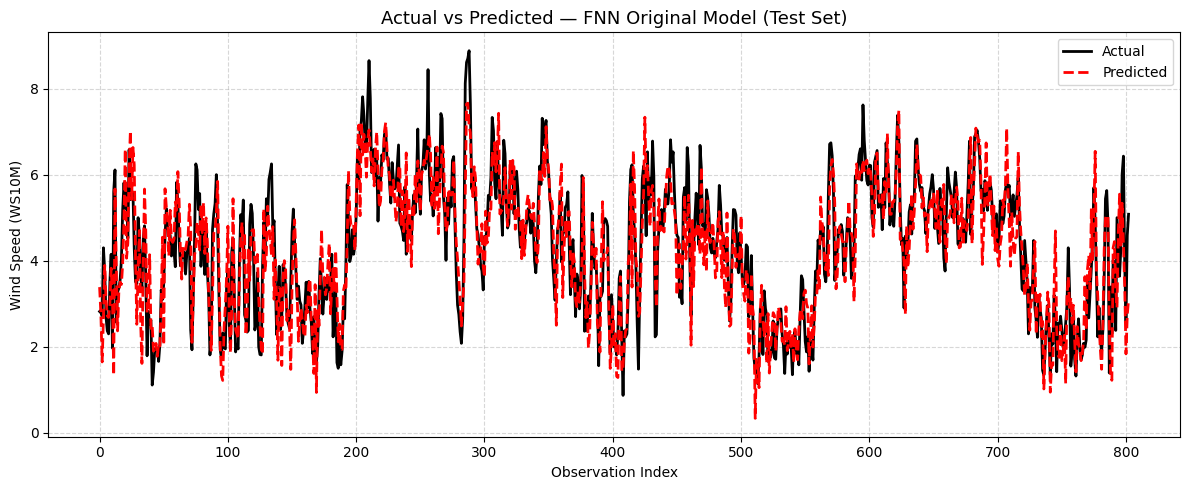

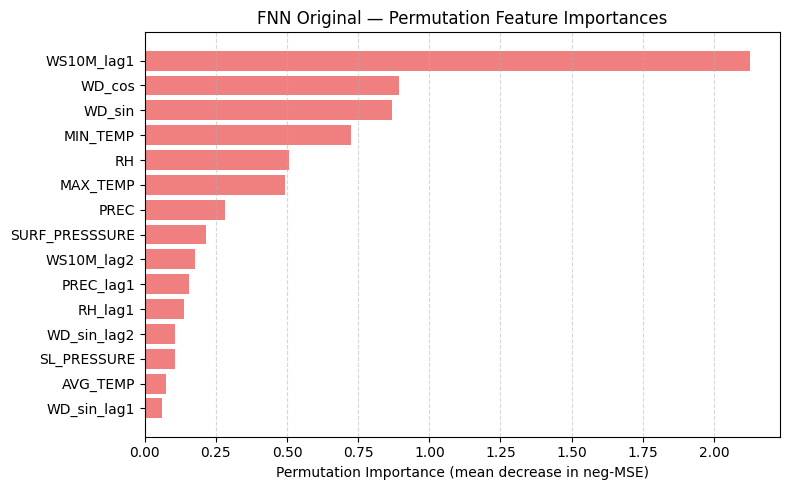

In [14]:
# ── FNN (MLPRegressor) with manually chosen default architecture ──
# hidden_layer_sizes=(100, 50): two hidden layers with 100 and 50 neurons
# activation='relu': rectified linear unit — common default for regression
# solver='adam': adaptive moment estimation — robust optimiser
# learning_rate='adaptive': reduces LR when training loss stops improving

fnn_original = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=1000,
    random_state=RANDOM_SEED
)

# Fit on scaled training data
fnn_original.fit(X_train_scaled, y_train)

# Predict on both splits
y_train_pred_orig = fnn_original.predict(X_train_scaled)
y_test_pred_orig  = fnn_original.predict(X_test_scaled)

# ── Performance Evaluation ──
print('=' * 50)
print('  FNN — ORIGINAL MODEL (Default Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train, y_train_pred_orig, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test, y_test_pred_orig, label='Test ')

# Store results for summary table
results_store['Original Model'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# Create a DataFrame to compare actual and predicted values on the test set
comparison_df = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': y_test_pred_orig
}, index=y_test.index)
print('\nFirst 20 test predictions:')
print(comparison_df.head(20))

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test, y_test_pred_orig,
    title='Actual vs Predicted — FNN Original Model (Test Set)',
    color='red'
)

# ── Permutation Feature Importance ──
# MLPRegressor has no feature_importances_; permutation importance is used instead.
imp_orig = plot_permutation_importance(
    fnn_original, X_test_scaled, y_test,
    feature_names=X_test.columns.tolist(),
    title='FNN Original — Permutation Feature Importances',
    color='lightcoral'
)

# ─────────────────────────────────────────
# SECTION 7 — FNN: GRID SEARCH
#             (Exhaustive hyperparameter search)
# ─────────────────────────────────────────

Fitting 5 folds for each of 64 candidates, totalling 320 fits

Best Parameters (Grid Search):
{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (150, 100, 50), 'learning_rate': 'constant', 'max_iter': 100, 'solver': 'adam'}
Best CV Score (neg-MSE): -0.5209

  FNN — GRID SEARCH (Optimised Parameters)

[Training Set]
Train MSE  : 0.2549
Train RMSE : 0.5049
Train MAE  : 0.3930
Train MAPE : 10.79%
Train R²   : 0.8988

[Test Set]
Test  MSE  : 0.5550
Test  RMSE : 0.7450
Test  MAE  : 0.5801
Test  MAPE : 16.00%
Test  R²   : 0.7699


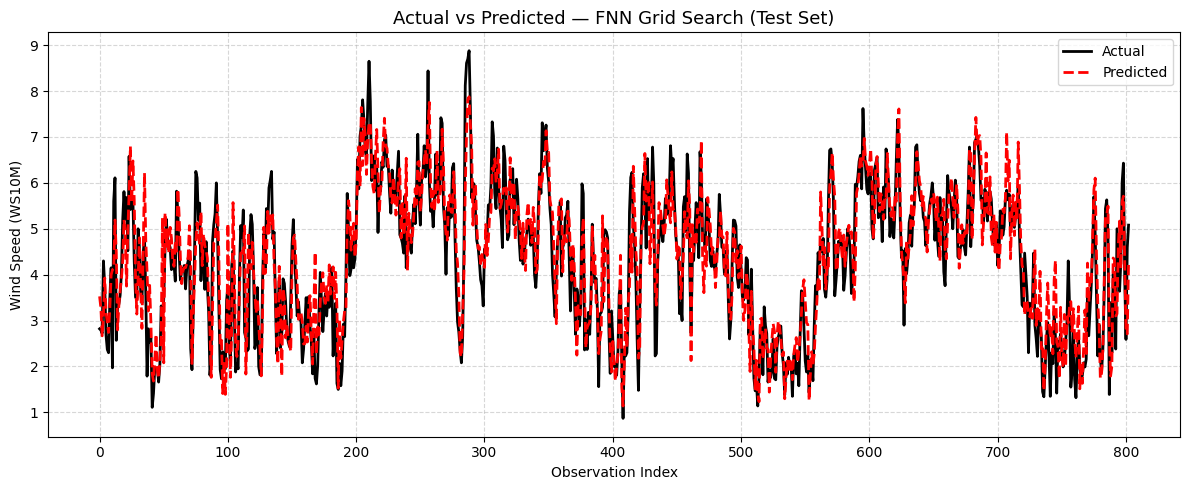

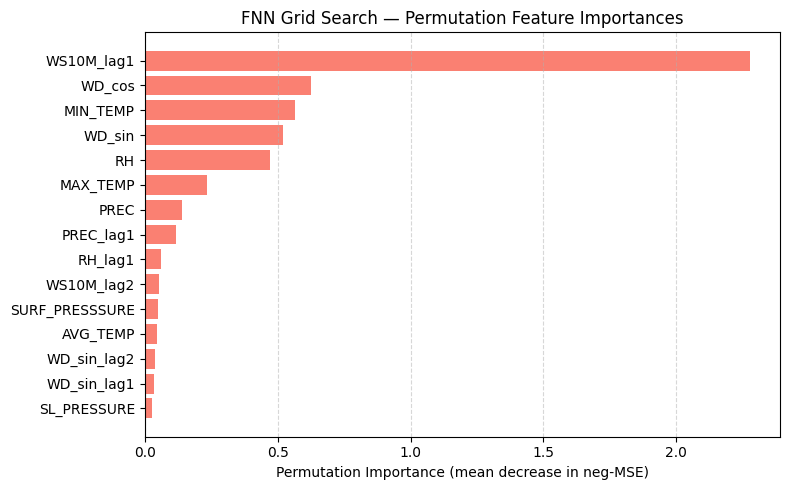

In [15]:
# ── Hyperparameter grid for exhaustive search ──
# Each combination is evaluated via TimeSeriesSplit CV on training data
param_grid = {
    'hidden_layer_sizes': [(50,), (75,), (100, 50), (150, 100, 50)],
    'activation'        : ['relu', 'tanh'],
    'solver'            : ['adam'],
    'learning_rate'     : ['constant', 'adaptive'],
    'alpha'             : [0.001, 0.01],  # L2 penalty (regularization)
    'max_iter'          : [100, 200]
}

# ── TimeSeriesSplit: 5-fold CV applied to TRAINING DATA ONLY ──
# Ensures future observations never appear in a validation fold during tuning.
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=MLPRegressor(random_state=RANDOM_SEED),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

# Fit Grid Search on scaled training data only
grid_search.fit(X_train_scaled, y_train)

print('\nBest Parameters (Grid Search):')
print(grid_search.best_params_)
print(f'Best CV Score (neg-MSE): {grid_search.best_score_:.4f}')

# ── Refit best model on full training set (done automatically by GridSearchCV) ──
best_fnn_grid = grid_search.best_estimator_

# Predict on both splits
y_train_pred_grid = best_fnn_grid.predict(X_train_scaled)
y_test_pred_grid  = best_fnn_grid.predict(X_test_scaled)

# ── Performance Evaluation ──
print('\n' + '=' * 50)
print('  FNN — GRID SEARCH (Optimised Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train, y_train_pred_grid, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test, y_test_pred_grid, label='Test ')

# Store results for summary table
results_store['Grid Search'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test, y_test_pred_grid,
    title='Actual vs Predicted — FNN Grid Search (Test Set)',
    color='red'
)

# ── Permutation Feature Importance ──
imp_grid = plot_permutation_importance(
    best_fnn_grid, X_test_scaled, y_test,
    feature_names=X_test.columns.tolist(),
    title='FNN Grid Search — Permutation Feature Importances',
    color='salmon'
)

# ─────────────────────────────────────────
# SECTION 8 — FNN: RANDOMIZED SEARCH
#             (Stochastic hyperparameter search)
# ─────────────────────────────────────────

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters (Randomized Search):
{'solver': 'adam', 'max_iter': 100, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (150, 100, 50), 'alpha': 0.01, 'activation': 'relu'}
Best CV Score (neg-MSE): -0.5209

  FNN — RANDOMIZED SEARCH (Optimised Parameters)

[Training Set]
Train MSE  : 0.2549
Train RMSE : 0.5049
Train MAE  : 0.3930
Train MAPE : 10.79%
Train R²   : 0.8988

[Test Set]
Test  MSE  : 0.5550
Test  RMSE : 0.7450
Test  MAE  : 0.5801
Test  MAPE : 16.00%
Test  R²   : 0.7699


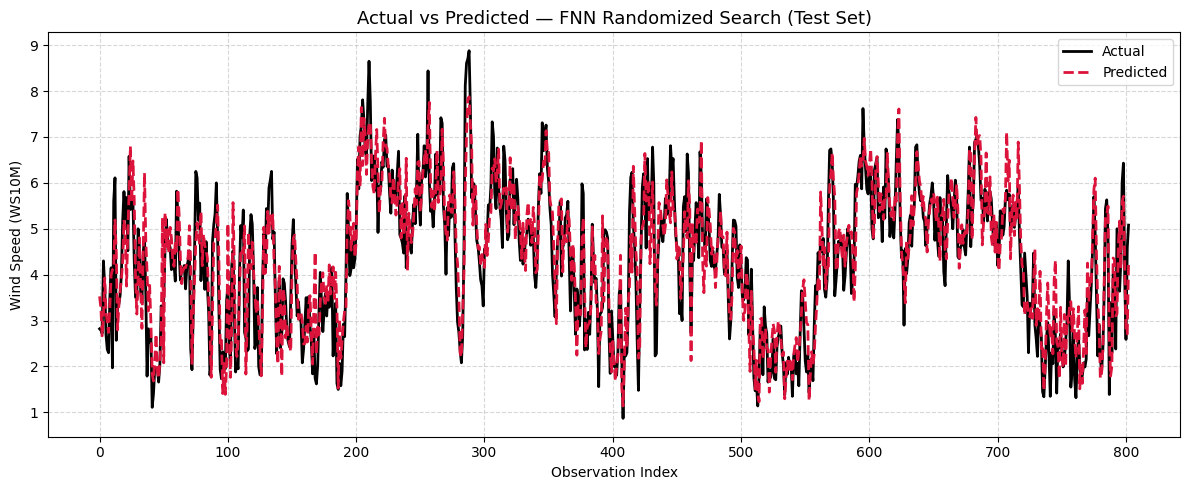

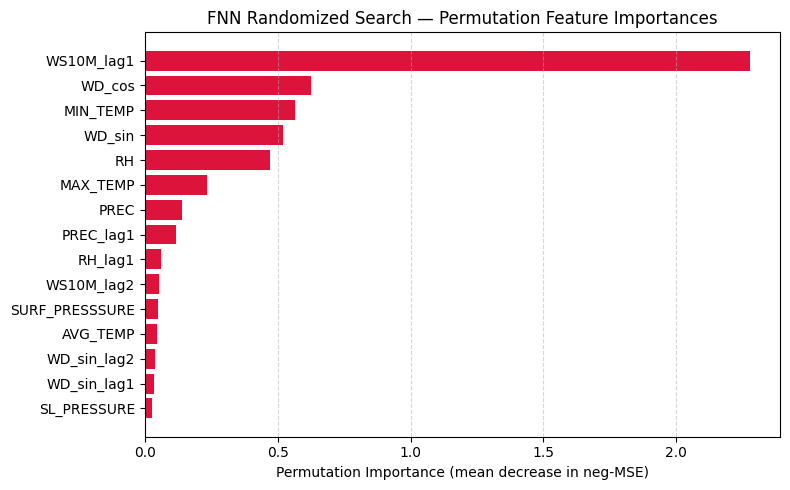

In [16]:
# ── Mixed discrete and continuous distributions for random sampling ──
param_dist = {
    'hidden_layer_sizes': [(50,), (75,), (100, 50), (150, 100, 50)],
    'activation'        : ['relu', 'tanh'],
    'solver'            : ['adam'],
    'learning_rate'     : ['constant', 'adaptive'],
    'alpha'             : [0.001, 0.01],  # L2 penalty (regularization)
    'max_iter'          : [100, 200]
}

# ── TimeSeriesSplit: 5-fold CV applied to TRAINING DATA ONLY ──
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=MLPRegressor(random_state=RANDOM_SEED),
    param_distributions=param_dist,
    n_iter=50,                          # Number of random parameter combinations to try
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# Fit Randomized Search on scaled training data only
random_search.fit(X_train_scaled, y_train)

print('\nBest Parameters (Randomized Search):')
print(random_search.best_params_)
print(f'Best CV Score (neg-MSE): {random_search.best_score_:.4f}')

# ── Refit best model on full training set ──
best_fnn_random = random_search.best_estimator_

# Predict on both splits
y_train_pred_random = best_fnn_random.predict(X_train_scaled)
y_test_pred_random  = best_fnn_random.predict(X_test_scaled)

# ── Performance Evaluation ──
print('\n' + '=' * 50)
print('  FNN — RANDOMIZED SEARCH (Optimised Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train, y_train_pred_random, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test, y_test_pred_random, label='Test ')

# Store results for summary table
results_store['Randomized Search'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test, y_test_pred_random,
    title='Actual vs Predicted — FNN Randomized Search (Test Set)',
    color='crimson'
)

# ── Permutation Feature Importance ──
# Permutation importance is used because MLPRegressor has no feature_importances_
imp_random = plot_permutation_importance(
    best_fnn_random, X_test_scaled, y_test,
    feature_names=X_test.columns.tolist(),
    title='FNN Randomized Search — Permutation Feature Importances',
    color='crimson'
)

# ─────────────────────────────────────────
# SECTION 9 — FNN: OPTUNA
#             (TPE-based Bayesian optimisation)
# ─────────────────────────────────────────


Best Trial:
  Value (mean CV RMSE): 0.7139

Best Parameters (Optuna):
{'n_layers': 2, 'n_units_l0': 53, 'n_units_l1': 40, 'activation': 'relu', 'alpha': 0.03606779241809679, 'learning_rate': 'constant'}

  FNN — OPTUNA (Optimised Parameters)

[Training Set]
Train MSE  : 0.3423
Train RMSE : 0.5851
Train MAE  : 0.4573
Train MAPE : 12.75%
Train R²   : 0.8641

[Test Set]
Test  MSE  : 0.5384
Test  RMSE : 0.7337
Test  MAE  : 0.5680
Test  MAPE : 15.29%
Test  R²   : 0.7767


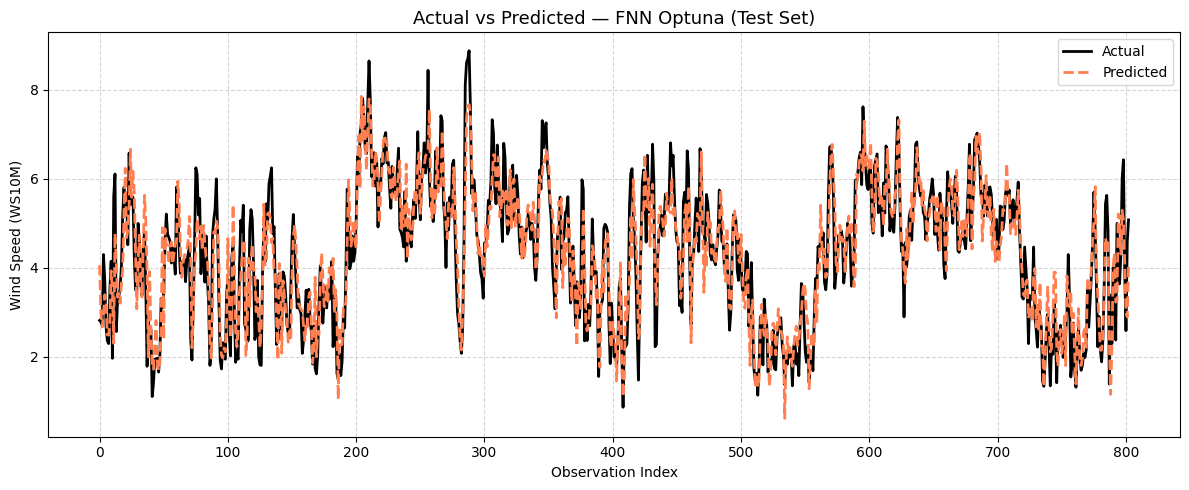

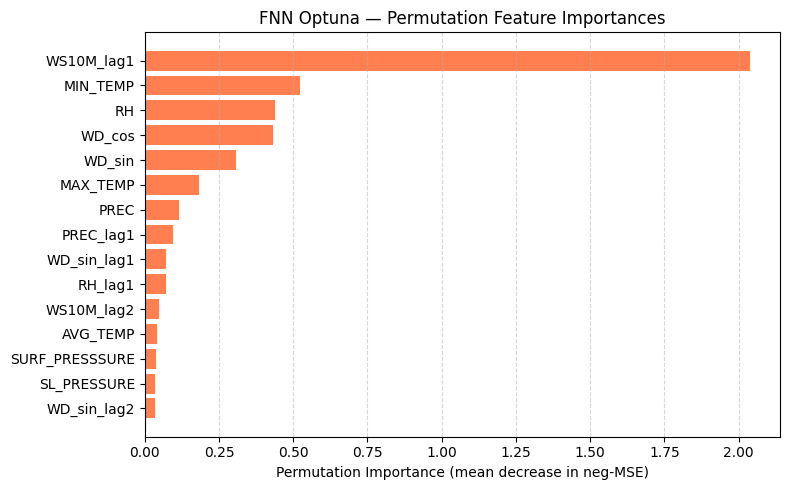

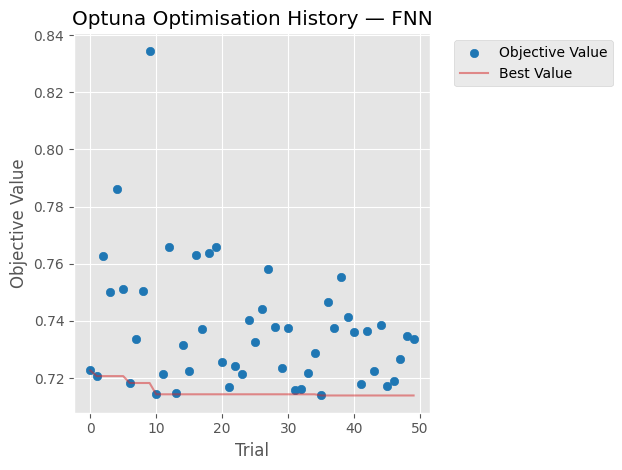

In [17]:
# ── Optuna objective function ──
# Performs TimeSeriesSplit CV on TRAINING DATA ONLY.
# Test data is never touched during optimisation (no data leakage).

def fnn_objective(trial):
    # Dynamically suggest number of hidden layers and units per layer
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_layer_sizes = tuple(
        trial.suggest_int(f'n_units_l{i}', 20, 70)
        for i in range(n_layers)
    )

    params = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation'        : trial.suggest_categorical('activation', ['relu', 'tanh']),
        'solver'            : 'adam',    # Fixed — adam is robust for FNNs
        'alpha'             : trial.suggest_float('alpha', 1e-2, 1e-1, log=True),  # L2 regularization
        'learning_rate'     : trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'max_iter'          : 200,
        'random_state'      : RANDOM_SEED
    }

    tscv = TimeSeriesSplit(n_splits=5)
    fold_rmse = []

    for train_idx, val_idx in tscv.split(X_train_scaled):
        # ── Use pre-scaled numpy arrays — DO NOT re-fit the scaler per fold ──
        # Re-fitting inside CV would leak validation statistics into the scaler.
        X_fold_tr, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_tr, y_fold_val = y_train.iloc[train_idx],   y_train.iloc[val_idx]

        model = MLPRegressor(**params)
        model.fit(X_fold_tr, y_fold_tr)
        preds = model.predict(X_fold_val)

        # Compute RMSE for this fold
        fold_rmse.append(np.sqrt(mean_squared_error(y_fold_val, preds)))

    return np.mean(fold_rmse)   # Minimise mean RMSE across folds


# ── Run Optuna study ──
# TPE (Tree-structured Parzen Estimator) sampler is Optuna's default and is
# more sample-efficient than a purely random sampler.
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study.optimize(fnn_objective, n_trials=50, timeout=600)  # Max 50 trials or 10 min

print('\nBest Trial:')
print(f'  Value (mean CV RMSE): {study.best_trial.value:.4f}')
print('\nBest Parameters (Optuna):')
print(study.best_params)

# ── Reconstruct hidden_layer_sizes from Optuna best params ──
best_params = study.best_params
hidden_layer_sizes = tuple(
    best_params[f'n_units_l{i}']
    for i in range(best_params['n_layers'])
)

# ── Refit FNN on full training set with best hyperparameters ──
best_fnn_optuna = MLPRegressor(
    hidden_layer_sizes=hidden_layer_sizes,
    activation=best_params['activation'],
    solver='adam',
    alpha=best_params['alpha'],
    learning_rate=best_params['learning_rate'],
    max_iter=1000,
    random_state=RANDOM_SEED
)
best_fnn_optuna.fit(X_train_scaled, y_train)

# Predict on both splits
y_train_pred_optuna = best_fnn_optuna.predict(X_train_scaled)
y_test_pred_optuna  = best_fnn_optuna.predict(X_test_scaled)

# ── Performance Evaluation ──
print('\n' + '=' * 50)
print('  FNN — OPTUNA (Optimised Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train, y_train_pred_optuna, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test, y_test_pred_optuna, label='Test ')

# Store results for summary table
results_store['Optuna'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test, y_test_pred_optuna,
    title='Actual vs Predicted — FNN Optuna (Test Set)',
    color='coral'
)

# ── Permutation Feature Importance ──
imp_optuna = plot_permutation_importance(
    best_fnn_optuna, X_test_scaled, y_test,
    feature_names=X_test.columns.tolist(),
    title='FNN Optuna — Permutation Feature Importances',
    color='coral'
)

# ── Optuna optimisation history plot ──
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optuna Optimisation History — FNN')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# SECTION 10 — PERFORMANCE COMPARISON TABLE
#              All four methods side-by-side
# ─────────────────────────────────────────


  FNN PERFORMANCE SUMMARY — DATASET 1
  (80% Train / 20% Test  |  TimeSeriesSplit CV on train only)
+-------------------+--------------+-------------+--------------+------------+-------------+------------+-------------+-----------+
| Method            |   Train RMSE |   Train MAE |   Train MAPE |   Train R² |   Test RMSE |   Test MAE |   Test MAPE |   Test R² |
+===================+==============+=============+==============+============+=============+============+=============+===========+
| Original Model    |       0.3892 |      0.2917 |       7.4600 |     0.9399 |      0.8228 |     0.6364 |     17.1800 |    0.7193 |
+-------------------+--------------+-------------+--------------+------------+-------------+------------+-------------+-----------+
| Grid Search       |       0.5049 |      0.3930 |      10.7900 |     0.8988 |      0.7450 |     0.5801 |     16.0000 |    0.7699 |
+-------------------+--------------+-------------+--------------+------------+-------------+------------+--

,Method,Train RMSE,Train MAE,Train MAPE,Train R²,Test RMSE,Test MAE,Test MAPE,Test R²
0,Original Model,0.3892,0.2917,7.46,0.9399,0.8228,0.6364,17.18,0.7193
1,Grid Search,0.5049,0.3930,10.79,0.8988,0.7450,0.5801,16.00,0.7699
2,Randomized Search,0.5049,0.3930,10.79,0.8988,0.7450,0.5801,16.00,0.7699
3,Optuna,0.5851,0.4573,12.75,0.8641,0.7337,0.5680,15.29,0.7767


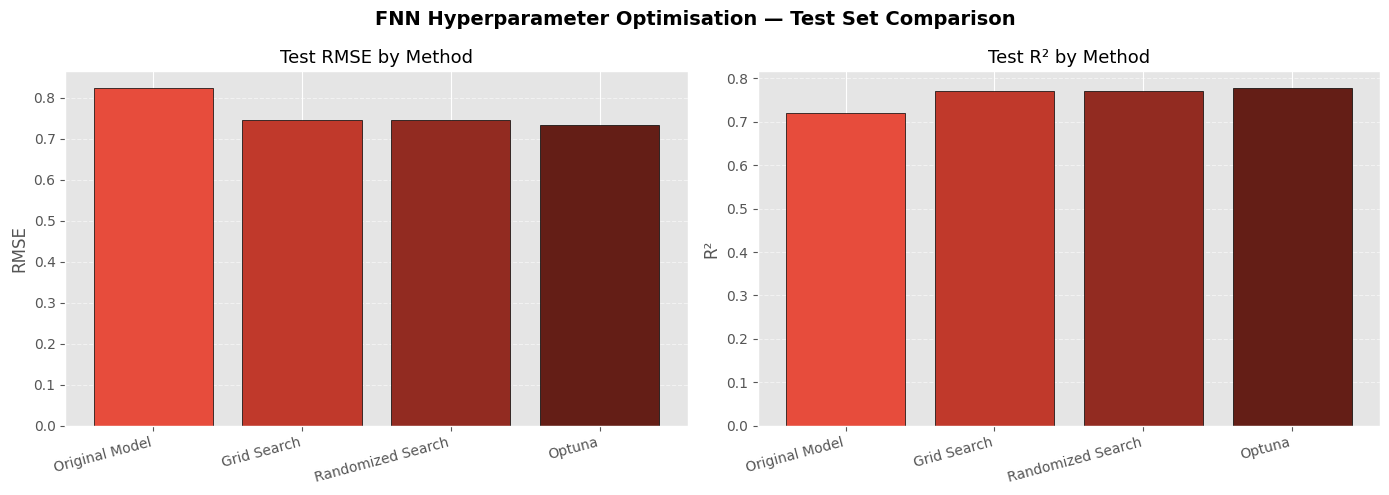

In [18]:
# ── Build the comparison DataFrame ──
methods = ['Original Model', 'Grid Search', 'Randomized Search', 'Optuna']

summary_data = []
for method in methods:
    r = results_store[method]
    summary_data.append({
        'Method'    : method,
        'Train RMSE': round(r['Train RMSE'], 4),
        'Train MAE' : round(r['Train MAE'],  4),
        'Train MAPE': round(r['Train MAPE'], 2),
        'Train R²'  : round(r['Train R2'],   4),
        'Test RMSE' : round(r['Test RMSE'],  4),
        'Test MAE'  : round(r['Test MAE'],   4),
        'Test MAPE' : round(r['Test MAPE'],  2),
        'Test R²'   : round(r['Test R2'],    4)
    })

summary_df = pd.DataFrame(summary_data)

# ── Pretty-print with tabulate ──
print('\n' + '=' * 80)
print('  FNN PERFORMANCE SUMMARY — DATASET 1')
print('  (80% Train / 20% Test  |  TimeSeriesSplit CV on train only)')
print('=' * 80)
print(tabulate(summary_df, headers='keys', tablefmt='grid',
               showindex=False, floatfmt='.4f'))

# ── Display as styled pandas table ──
display(summary_df.style
        .set_caption('FNN — Hyperparameter Optimisation Comparison (Dataset 1)')
        .highlight_min(subset=['Test RMSE', 'Test MAE', 'Test MAPE'], color='lightgreen')
        .highlight_max(subset=['Test R²'],                             color='lightgreen')
        .format({
            'Train RMSE': '{:.4f}', 'Train MAE': '{:.4f}',
            'Train MAPE': '{:.2f}', 'Train R²' : '{:.4f}',
            'Test RMSE' : '{:.4f}', 'Test MAE' : '{:.4f}',
            'Test MAPE' : '{:.2f}', 'Test R²'  : '{:.4f}'
        })
)

# ── Bar chart comparison (Test RMSE and Test R²) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#E74C3C', '#C0392B', '#922B21', '#641E16']

axes[0].bar(summary_df['Method'], summary_df['Test RMSE'], color=colors, edgecolor='black')
axes[0].set_title('Test RMSE by Method', fontsize=13)
axes[0].set_ylabel('RMSE')
axes[0].set_xticklabels(summary_df['Method'], rotation=15, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].bar(summary_df['Method'], summary_df['Test R²'], color=colors, edgecolor='black')
axes[1].set_title('Test R² by Method', fontsize=13)
axes[1].set_ylabel('R²')
axes[1].set_xticklabels(summary_df['Method'], rotation=15, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('FNN Hyperparameter Optimisation — Test Set Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()